In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
DATA_DIR = Path(
    r"D:\University\Machine Learning\Dataset\Data_Training_Soft_NPZ"
)

RAIN_IDX = 0          # 👈 đổi nếu rain không phải kênh 0
CHANNEL_FIRST = True  # True nếu shape = (C, H, W)

In [11]:
import numpy as np

npz_path = r"D:\University\Machine Learning\Dataset\Data_Training_Soft_NPZ\Sample_2020-01-03.npz"

data = np.load(npz_path)

print("📂 File:", npz_path)
print("🔑 Keys:", data.files)
print("=" * 60)

# Lấy array chính (thường chỉ có 1 key)
arr = data[data.files[0]]

print("📐 Array shape:", arr.shape)
print("📦 Dtype:", arr.dtype)
print("=" * 60)

# Kiểm tra layout
if arr.ndim != 3:
    raise ValueError("❌ Data không phải dạng 3D (channel, H, W) hoặc (H, W, channel)")

# Xác định channel dimension
if arr.shape[0] == 8:
    print("✅ Layout: (C, H, W)")
    CHANNEL_FIRST = True
elif arr.shape[-1] == 8:
    print("✅ Layout: (H, W, C)")
    CHANNEL_FIRST = False
else:
    raise ValueError("❌ Không tìm thấy 8 channel trong data")

print("=" * 60)

# In thông tin từng channel
for i in range(8):
    if CHANNEL_FIRST:
        ch = arr[i]
    else:
        ch = arr[:, :, i]

    print(f"🟦 Channel {i}")
    print("  Shape:", ch.shape)
    print("  Min:", np.nanmin(ch))
    print("  Max:", np.nanmax(ch))
    print("  Mean:", np.nanmean(ch))
    print("  Std:", np.nanstd(ch))
    print("  NaN count:", np.isnan(ch).sum())
    print("  Unique (sample):", np.unique(ch[~np.isnan(ch)])[:10])
    print("-" * 60)

📂 File: D:\University\Machine Learning\Dataset\Data_Training_Soft_NPZ\Sample_2020-01-03.npz
🔑 Keys: ['x', 'y']
📐 Array shape: (8, 1115, 1856)
📦 Dtype: float32
✅ Layout: (C, H, W)
🟦 Channel 0
  Shape: (1115, 1856)
  Min: 0.0
  Max: 0.0
  Mean: 0.0
  Std: 0.0
  NaN count: 0
  Unique (sample): [0.]
------------------------------------------------------------
🟦 Channel 1
  Shape: (1115, 1856)
  Min: 0.0
  Max: 11.962006
  Mean: 7.469934
  Std: 4.013294
  NaN count: 0
  Unique (sample): [0.00000000e+00 1.44695505e-05 2.89391010e-05 4.34086505e-05
 5.78782019e-05 7.23477497e-05 8.68173011e-05 1.01286852e-04
 1.15756404e-04 1.30225948e-04]
------------------------------------------------------------
🟦 Channel 2
  Shape: (1115, 1856)
  Min: 0.0
  Max: 0.0
  Mean: 0.0
  Std: 0.0
  NaN count: 0
  Unique (sample): [0.]
------------------------------------------------------------
🟦 Channel 3
  Shape: (1115, 1856)
  Min: 0.0
  Max: 0.0
  Mean: 0.0
  Std: 0.0
  NaN count: 0
  Unique (sample): [0.]
-

Array shape: (8, 1115, 1856)


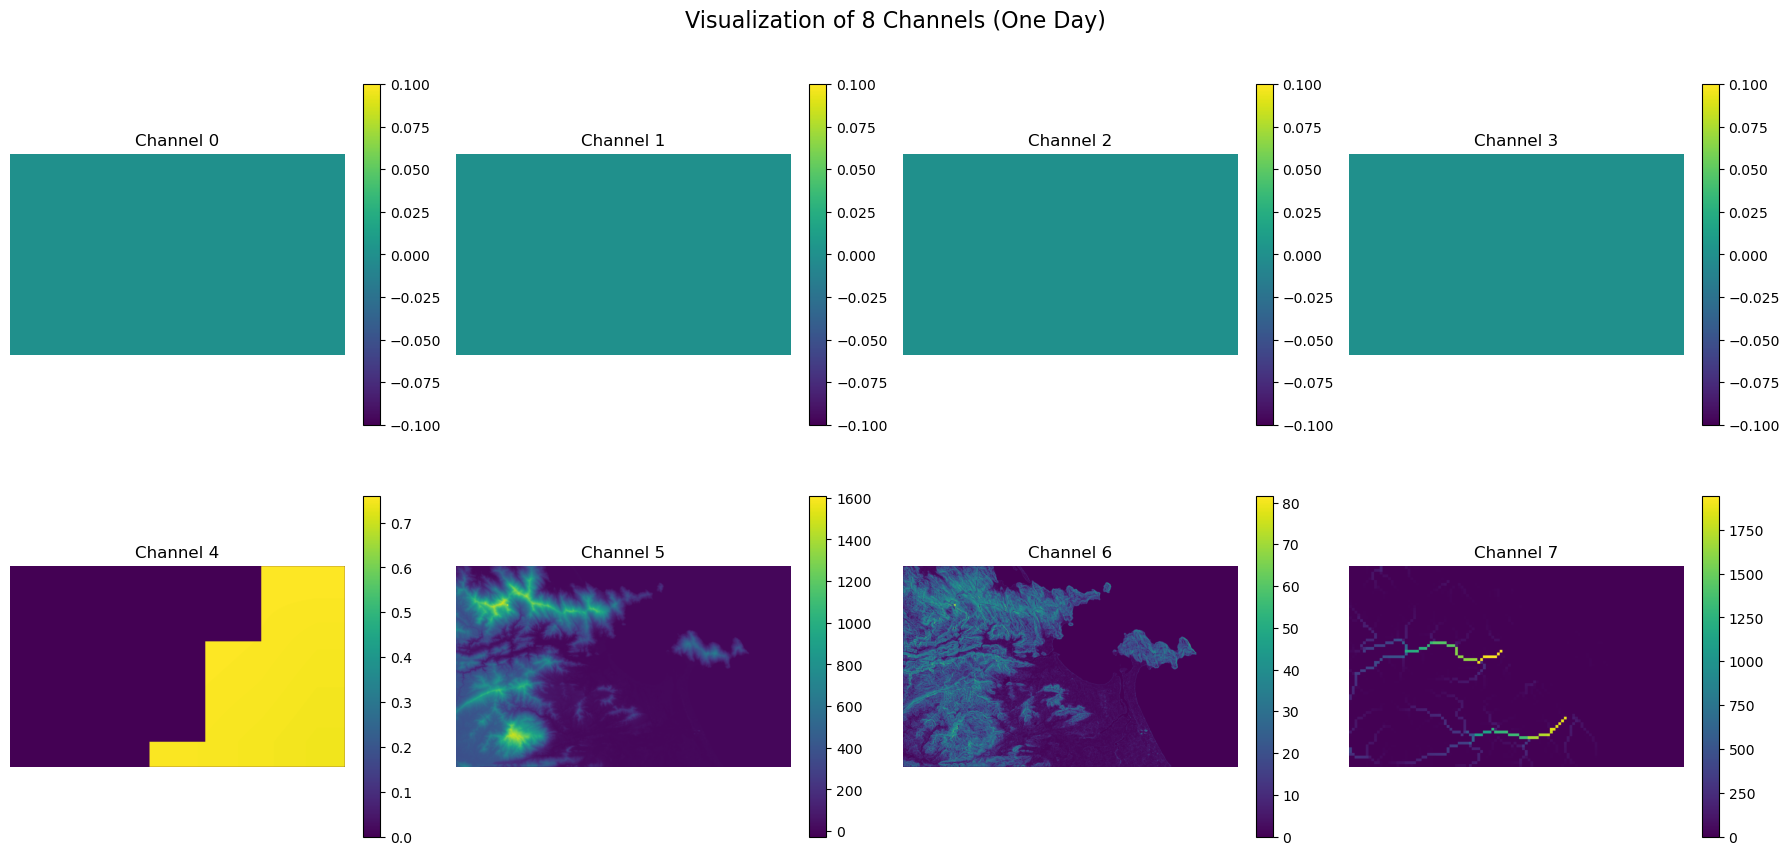

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ====== CONFIG ======
npz_path = r"D:\University\Machine Learning\Dataset\Data_Training_Soft_NPZ\Sample_2020-02-16.npz"

# ====================
data = np.load(npz_path)
arr = data[data.files[0]]  # lấy array chính

print("Array shape:", arr.shape)

# Xác định layout
if arr.shape[0] == 8:
    CHANNEL_FIRST = True   # (C, H, W)
elif arr.shape[-1] == 8:
    CHANNEL_FIRST = False  # (H, W, C)
else:
    raise ValueError("❌ Không tìm thấy 8 channel")

# ====== VISUALIZE ======
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, ax in enumerate(axes.flat):
    if CHANNEL_FIRST:
        ch = arr[i]
    else:
        ch = arr[:, :, i]

    im = ax.imshow(ch, cmap="viridis")
    ax.set_title(f"Channel {i}", fontsize=12)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Visualization of 8 Channels (One Day)", fontsize=16)
plt.tight_layout()
plt.show()

In [22]:
import numpy as np
import matplotlib.pyplot as plt

npz_path = r"D:\University\Machine Learning\Dataset\Data_Training_Soft_NPZ\Sample_2020-01-03.npz"

data = np.load(npz_path)
arr = data[data.files[0]]

# xác định layout
if arr.shape[0] == 8:
    CHANNEL_FIRST = True
elif arr.shape[-1] == 8:
    CHANNEL_FIRST = False
else:
    raise ValueError("Không tìm thấy 8 channel")

In [23]:
print("=== Missing Data Summary (1 day) ===")
for i in range(8):
    ch = arr[i] if CHANNEL_FIRST else arr[:, :, i]

    nan_count = np.isnan(ch).sum()
    total = ch.size
    ratio = nan_count / total * 100

    print(f"Channel {i}: NaN = {nan_count} ({ratio:.2f}%)")

=== Missing Data Summary (1 day) ===
Channel 0: NaN = 0 (0.00%)
Channel 1: NaN = 0 (0.00%)
Channel 2: NaN = 0 (0.00%)
Channel 3: NaN = 0 (0.00%)
Channel 4: NaN = 0 (0.00%)
Channel 5: NaN = 0 (0.00%)
Channel 6: NaN = 0 (0.00%)
Channel 7: NaN = 0 (0.00%)


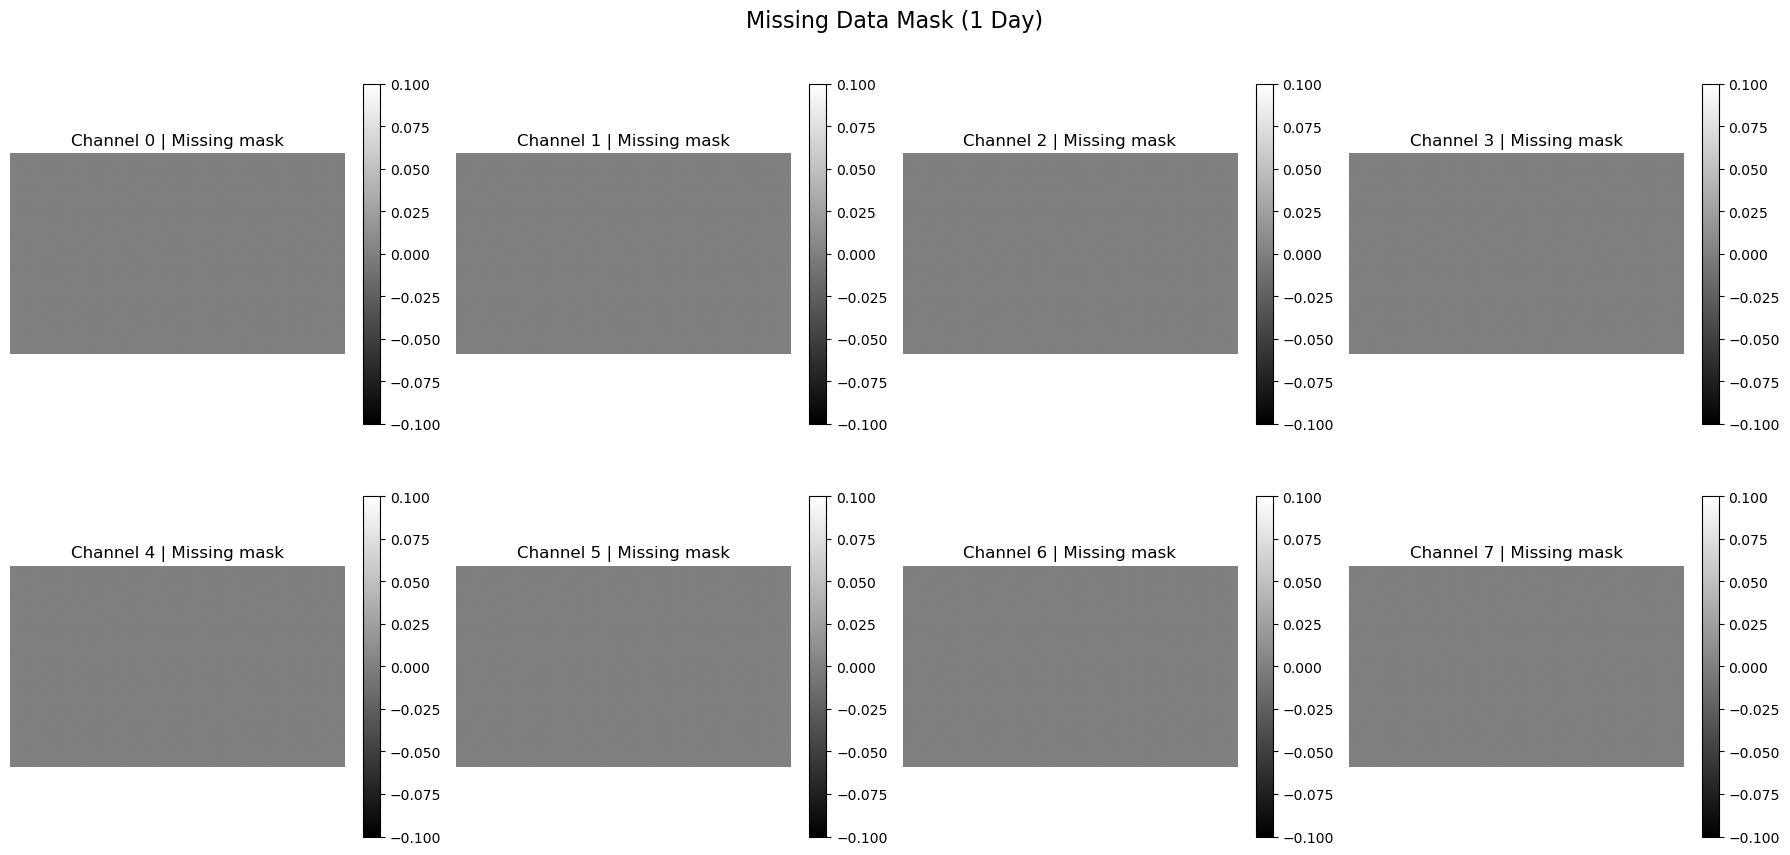

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, ax in enumerate(axes.flat):
    ch = arr[i] if CHANNEL_FIRST else arr[:, :, i]
    mask = np.isnan(ch)

    im = ax.imshow(mask, cmap="gray")
    ax.set_title(f"Channel {i} | Missing mask")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Missing Data Mask (1 Day)", fontsize=16)
plt.tight_layout()
plt.show()

In [26]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
DATA_DIR = Path(
    r"D:\University\Machine Learning\Dataset\Data_Training_Soft_NPZ"
)

N_CHANNELS = 8

In [34]:
from pathlib import Path

DATA_DIR = Path(
    r"D:\University\Machine Learning\Dataset\Data_Training_Soft_NPZ"
)

files = list(DATA_DIR.glob("*.npz"))
print("Number of npz files:", len(files))
print("Sample files:", files[:5])

Number of npz files: 560
Sample files: [WindowsPath('D:/University/Machine Learning/Dataset/Data_Training_Soft_NPZ/Sample_2020-01-03.npz'), WindowsPath('D:/University/Machine Learning/Dataset/Data_Training_Soft_NPZ/Sample_2020-01-11.npz'), WindowsPath('D:/University/Machine Learning/Dataset/Data_Training_Soft_NPZ/Sample_2020-01-15.npz'), WindowsPath('D:/University/Machine Learning/Dataset/Data_Training_Soft_NPZ/Sample_2020-01-20.npz'), WindowsPath('D:/University/Machine Learning/Dataset/Data_Training_Soft_NPZ/Sample_2020-01-23.npz')]


In [35]:
def load_npz_safe(path):
    try:
        data = np.load(path)
        return data[data.files[0]]
    except Exception:
        return None

In [36]:
records = []

for npz in sorted(DATA_DIR.glob("*.npz")):
    # parse date từ tên file
    date_str = npz.stem.split("_")[-1]
    date = pd.to_datetime(date_str, errors="coerce")
    if date is pd.NaT:
        continue

    arr = load_npz_safe(npz)
    if arr is None:
        continue

    # xác định layout
    if arr.shape[0] == N_CHANNELS:
        CHANNEL_FIRST = True
    elif arr.shape[-1] == N_CHANNELS:
        CHANNEL_FIRST = False
    else:
        continue

    for ch in range(N_CHANNELS):
        channel_data = arr[ch] if CHANNEL_FIRST else arr[:, :, ch]

        mean_val = np.nanmean(channel_data)

        records.append({
            "date": date,
            "year": date.year,
            "dayofyear": date.dayofyear,
            "channel": ch,
            "value": mean_val
        })

df = pd.DataFrame(records)
df.head()

,date,year,dayofyear,channel,value
0,2020-01-03,2020,3,0,0.000000
1,2020-01-03,2020,3,1,7.469934
2,2020-01-03,2020,3,2,0.000000
3,2020-01-03,2020,3,3,0.000000
4,2020-01-03,2020,3,4,0.334321


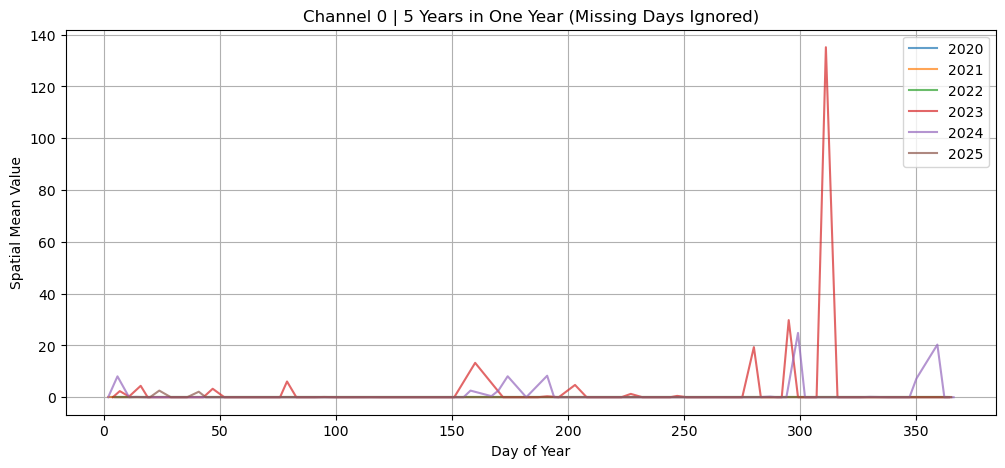

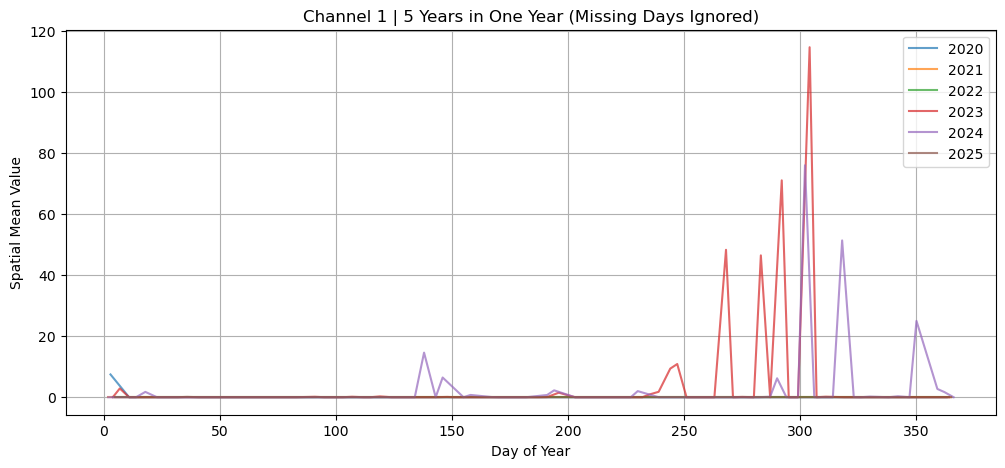

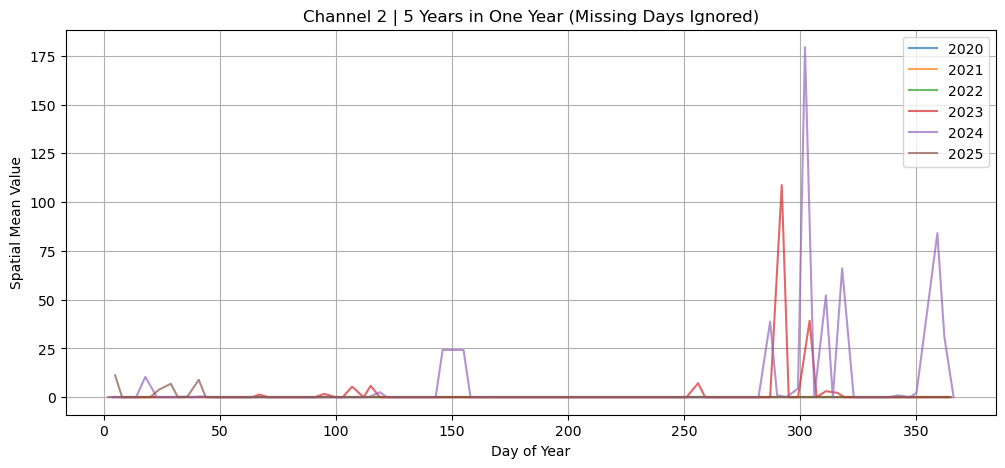

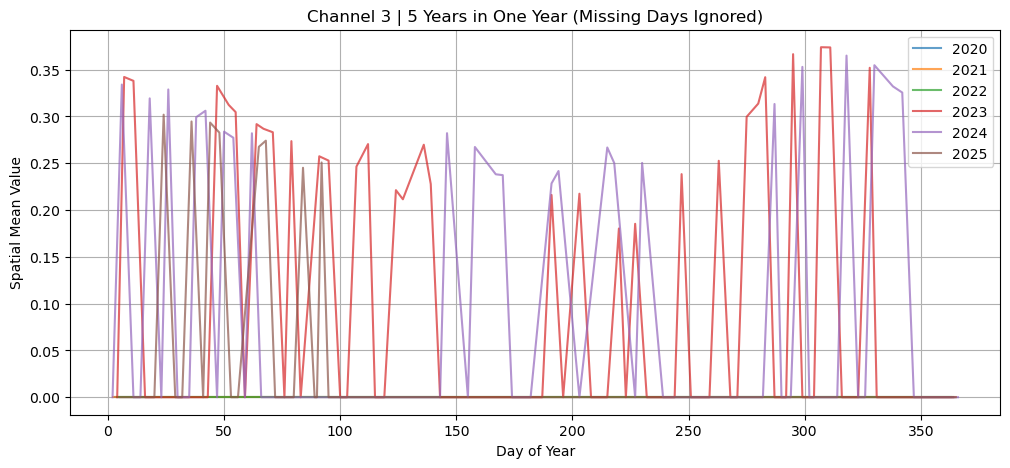

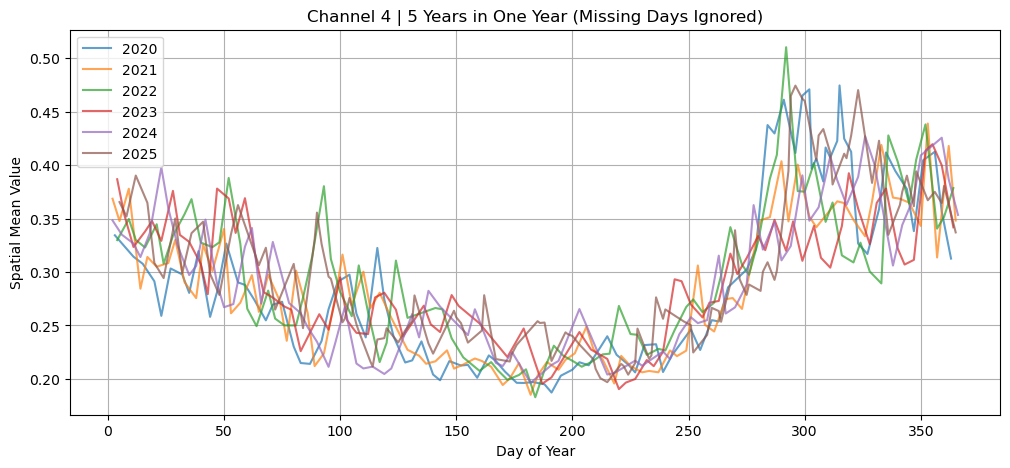

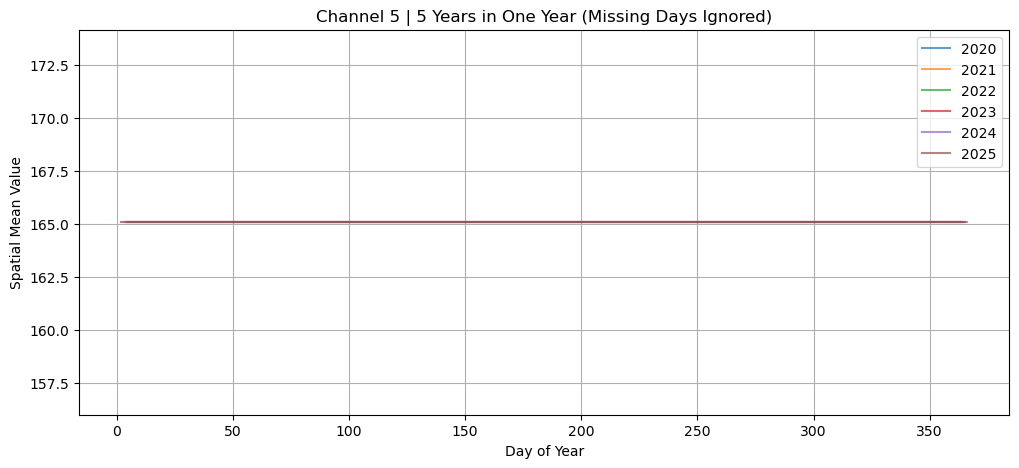

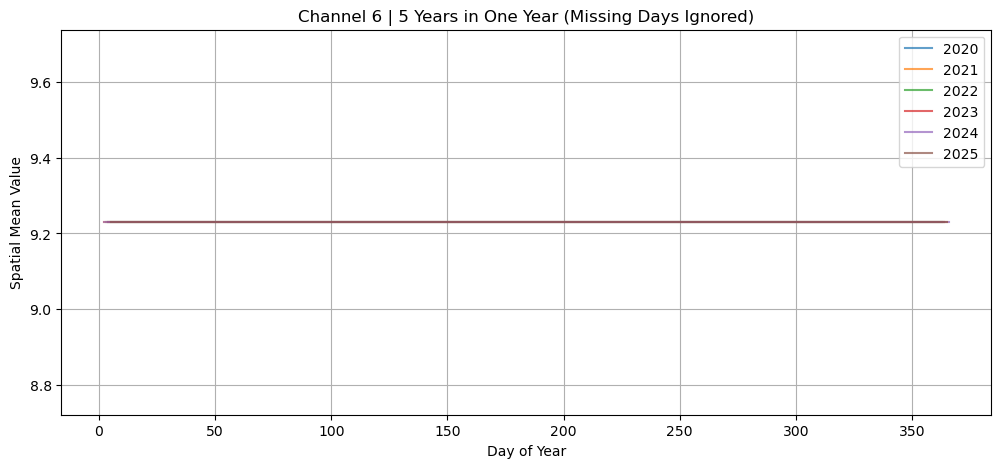

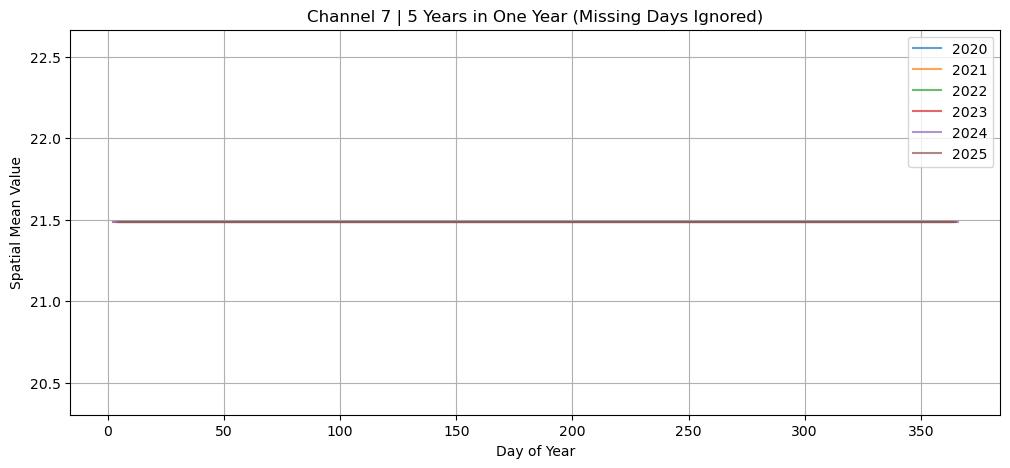

In [37]:
for ch in range(N_CHANNELS):
    plt.figure(figsize=(12,5))

    df_ch = df[df["channel"] == ch]

    for year, g in df_ch.groupby("year"):
        plt.plot(
            g["dayofyear"],
            g["value"],
            label=str(year),
            alpha=0.7
        )

    plt.xlabel("Day of Year")
    plt.ylabel("Spatial Mean Value")
    plt.title(f"Channel {ch} | 5 Years in One Year (Missing Days Ignored)")
    plt.legend()
    plt.grid(True)
    plt.show()

In [10]:
import numpy as np

npz_path = r"D:\University\Machine Learning\Dataset\Data_Training_Soft_NPZ\Sample_2020-01-03.npz"

data = np.load(npz_path)

print("🔹 File:", npz_path)
print("🔹 Keys in npz:", data.files)
print("-" * 50)

for k in data.files:
    arr = data[k]
    print(f"Key: {k}")
    print("  Shape:", arr.shape)
    print("  Dtype:", arr.dtype)
    print("  Min:", np.nanmin(arr))
    print("  Max:", np.nanmax(arr))
    print("  Mean:", np.nanmean(arr))
    print("-" * 50)

🔹 File: D:\University\Machine Learning\Dataset\Data_Training_Soft_NPZ\Sample_2020-01-03.npz
🔹 Keys in npz: ['x', 'y']
--------------------------------------------------
Key: x
  Shape: (8, 1115, 1856)
  Dtype: float32
  Min: -26.0
  Max: 1943.0
  Mean: 25.451637
--------------------------------------------------
Key: y
  Shape: (1115, 1856)
  Dtype: float32
  Min: 0.0
  Max: 0.0
  Mean: 0.0
--------------------------------------------------


In [4]:
def mean_rain_one_day_npz(npz_path):
    data = np.load(npz_path)

    # Lấy array chính (thường chỉ có 1 key)
    arr = data[data.files[0]]

    if CHANNEL_FIRST:
        rain = arr[RAIN_IDX, :, :]
    else:
        rain = arr[:, :, RAIN_IDX]

    rain = rain.astype(np.float32)

    # loại giá trị invalid nếu có
    rain[rain < 0] = np.nan

    return np.nanmean(rain)

In [8]:
records = []

for npz in sorted(DATA_DIR.glob("*.npz")):
    # Lấy ngày từ tên file
    date_str = npz.stem.split("_")[-1]
    date = pd.to_datetime(date_str)

    mean_rain = mean_rain_one_day_npz(npz)

    records.append({
        "date": date,
        "year": date.year,
        "dayofyear": date.dayofyear,
        "mean_rain": mean_rain
    })

df = pd.DataFrame(records)
df

,date,year,dayofyear,mean_rain
0,2020-01-03,2020,3,0.0
1,2020-01-11,2020,11,0.0
2,2020-01-15,2020,15,0.0
3,2020-01-20,2020,20,0.0
4,2020-01-23,2020,23,0.0
...,...,...,...,...
555,2025-12-19,2025,353,0.0
556,2025-12-22,2025,356,0.0
557,2025-12-25,2025,359,0.0
558,2025-12-26,2025,360,0.0


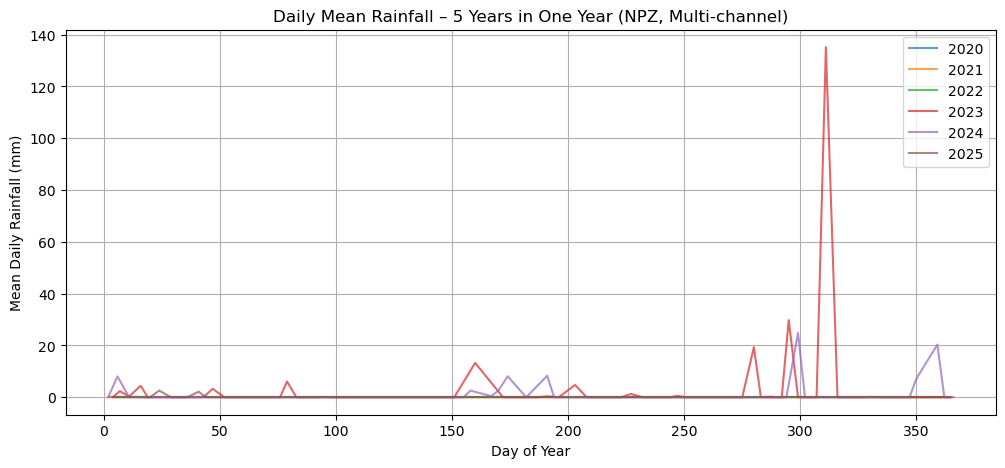

In [9]:
plt.figure(figsize=(12,5))

for year, g in df.groupby("year"):
    plt.plot(
        g["dayofyear"],
        g["mean_rain"],
        label=str(year),
        alpha=0.7
    )

plt.xlabel("Day of Year")
plt.ylabel("Mean Daily Rainfall (mm)")
plt.title("Daily Mean Rainfall – 5 Years in One Year (NPZ, Multi-channel)")
plt.legend()
plt.grid(True)
plt.show()